In [1]:
import os
import numpy as np
import pandas as pd

# Optional visualization imports kept (as in original), but not required for submission
import seaborn as sns
import matplotlib.pyplot as plt

from skimage.io import imread, imshow

# Use tf.keras to avoid standalone keras/protobuf incompatibilities in Kaggle images
import tensorflow as tf

print("TensorFlow:", tf.__version__)

# Kaggle paths: use the provided aerial-cactus-identification dataset
BASE_PATH = "../input/aerial-cactus-identification"
if not os.path.exists(BASE_PATH):
    # fallback for alternate mount structure shown by the user listing
    BASE_PATH = "../input/aerial-cactus-identification/aerial-cactus-identification"
print("BASE_PATH:", BASE_PATH)

TRAIN_CSV = os.path.join(BASE_PATH, "train.csv")
SAMPLE_SUB = os.path.join(BASE_PATH, "sample_submission.csv")
TRAIN_DIR = os.path.join(BASE_PATH, "train")
TEST_DIR = os.path.join(BASE_PATH, "test")

assert os.path.exists(TRAIN_CSV), f"Missing: {TRAIN_CSV}"
assert os.path.exists(SAMPLE_SUB), f"Missing: {SAMPLE_SUB}"
assert os.path.isdir(TRAIN_DIR), f"Missing dir: {TRAIN_DIR}"
assert os.path.isdir(TEST_DIR), f"Missing dir: {TEST_DIR}"

# Environment variables from original cell (safe no-op on CPU)
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# Reproducibility (doesn't change core logic; just stabilizes)
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)



2026-05-14 13:08:48.273847: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778764128.284555      55 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778764128.287749      55 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-14 13:08:48.303832: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

TensorFlow: 2.18.0
BASE_PATH: ../input/aerial-cactus-identification


In [2]:
# Load train labels and sample submission (used to guarantee correct test id ordering/format)
train = pd.read_csv(TRAIN_CSV)
sub = pd.read_csv(SAMPLE_SUB)

# Basic checks
assert set(["id", "has_cactus"]).issubset(train.columns)
assert set(["id", "has_cactus"]).issubset(sub.columns)

print("train shape:", train.shape)
print("sub shape:", sub.shape)
print(train.head())
print(sub.head())




train shape: (14175, 2)
sub shape: (3325, 2)
                                     id  has_cactus
0  2de8f189f1dce439766637e75df0ee27.jpg           1
1  36704d250f236238e7f996812c48235d.jpg           1
2  eacde22fdc8c175972a5768e3daa8bc9.jpg           1
3  5d442f834da5e57d22b24802c32a8ca8.jpg           1
4  152491e0daf75c0e669400300ff7e645.jpg           1
                                     id  has_cactus
0  09034a34de0e2015a8a28dfe18f423f6.jpg         0.5
1  134f04305c795d6d202502c2ce3578f3.jpg         0.5
2  41fad8d145e6c41868ce3617e30a2545.jpg         0.5
3  35f8a11352c8d41b6231bb33d8d09f7e.jpg         0.5
4  b77dc902b035887cbbc01920ce0e3151.jpg         0.5


In [3]:
# Load images into numpy arrays (32x32 RGB). Keep it simple and deterministic.
def load_images(ids, folder, target_size=(32, 32)):
    X = np.zeros((len(ids), target_size[0], target_size[1], 3), dtype=np.float32)
    for i, img_id in enumerate(ids):
        path = os.path.join(folder, img_id)
        img = imread(path)
        # Ensure 3 channels
        if img.ndim == 2:
            img = np.stack([img, img, img], axis=-1)
        elif img.shape[-1] == 4:
            img = img[..., :3]
        # Ensure expected size (dataset is 32x32 already)
        if img.shape[0] != target_size[0] or img.shape[1] != target_size[1]:
            img = (
                tf.image.resize(img, target_size, method="bilinear")
                .numpy()
                .astype(img.dtype)
            )
        X[i] = img.astype(np.float32)
    return X


y_train = train["has_cactus"].values.astype(np.float32)

# Load train images
X_train = load_images(train["id"].values, TRAIN_DIR)

# Load test images in the same order as sample_submission to ensure correct alignment
X_test = load_images(sub["id"].values, TEST_DIR)

print("X_train:", X_train.shape, X_train.dtype)
print("y_train:", y_train.shape, y_train.dtype, "pos_rate:", y_train.mean())
print("X_test :", X_test.shape, X_test.dtype)



X_train: (14175, 32, 32, 3) float32
y_train: (14175,) float32 pos_rate: 0.7497707
X_test : (3325, 32, 32, 3) float32


In [4]:
# Preprocess for ResNet50 (core logic: ResNet50-based model)
from tensorflow.keras.applications.resnet50 import preprocess_input

X_train_pp = preprocess_input(X_train.copy())
X_test_pp = preprocess_input(X_test.copy())

# Train/val split (simple, deterministic)
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_pp, y_train, test_size=0.15, random_state=SEED, stratify=y_train
)

print("Train split:", X_tr.shape, y_tr.shape)
print("Val split  :", X_val.shape, y_val.shape)



Train split: (12048, 32, 32, 3) (12048,)
Val split  : (2127, 32, 32, 3) (2127,)


In [5]:
# Build model: ResNet50 backbone + GAP + Dense/Dropout head (preserving the intended core approach)
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.models import Model

inp = Input(shape=(32, 32, 3))
base = ResNet50(include_top=False, weights="imagenet", input_tensor=inp)

x = base.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
out = Dense(1, activation="sigmoid")(x)

model = Model(inputs=inp, outputs=out)

# Common practice for transfer learning on small images: freeze backbone initially
for layer in base.layers:
    layer.trainable = False

model.summary()



2026-05-14 13:11:32.038989: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1778764292.039444      55 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:c5:00.0, compute capability: 8.6


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 38, 38, 3) │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 16, 16,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 16, 16,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 16, 16,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 18, 18,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 8, 8, 64)  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 8, 8, 64)  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_1_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 8, 8, 64)  │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_2_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 8, 8, 256) │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 8, 8, 256) │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_3_c

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [6]:
# Compile with binary crossentropy; fix deprecated args (Adam(lr=...) -> learning_rate)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Fix callback args: epsilon -> min_delta for modern TF/Keras
red = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.1,
    patience=10,
    verbose=1,
    mode="auto",
    min_delta=1e-4,
    cooldown=0,
    min_lr=0.0,
)
early_stopping = EarlyStopping(
    monitor="val_loss", patience=50, verbose=1, restore_best_weights=True
)

model.compile(
    loss="binary_crossentropy", optimizer=Adam(learning_rate=1e-4), metrics=["accuracy"]
)



In [7]:
# Train (no early stopping change beyond correctness; uses same idea as original code)
history = model.fit(
    X_tr,
    y_tr,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=[red, early_stopping],
    verbose=2,
)



Epoch 1/30


I0000 00:00:1778764298.694750     107 service.cc:148] XLA service 0x7f54ac003990 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778764298.694783     107 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2026-05-14 13:11:38.792387: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778764299.524257     107 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1778764301.067193     107 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


189/189 - 13s - 67ms/step - accuracy: 0.6516 - loss: 1.0380 - val_accuracy: 0.8185 - val_loss: 0.4115 - learning_rate: 1.0000e-04
Epoch 2/30
189/189 - 1s - 6ms/step - accuracy: 0.8127 - loss: 0.4885 - val_accuracy: 0.9182 - val_loss: 0.2160 - learning_rate: 1.0000e-04
Epoch 3/30
189/189 - 1s - 5ms/step - accuracy: 0.8761 - loss: 0.3210 - val_accuracy: 0.9473 - val_loss: 0.1533 - learning_rate: 1.0000e-04
Epoch 4/30
189/189 - 1s - 5ms/step - accuracy: 0.9110 - loss: 0.2325 - val_accuracy: 0.9586 - val_loss: 0.1257 - learning_rate: 1.0000e-04
Epoch 5/30
189/189 - 1s - 5ms/step - accuracy: 0.9248 - loss: 0.1963 - val_accuracy: 0.9647 - val_loss: 0.1076 - learning_rate: 1.0000e-04
Epoch 6/30
189/189 - 1s - 6ms/step - accuracy: 0.9321 - loss: 0.1803 - val_accuracy: 0.9657 - val_loss: 0.0980 - learning_rate: 1.0000e-04
Epoch 7/30
189/189 - 1s - 6ms/step - accuracy: 0.9405 - loss: 0.1553 - val_accuracy: 0.9704 - val_loss: 0.0903 - learning_rate: 1.0000e-04
Epoch 8/30
189/189 - 1s - 5ms/step -

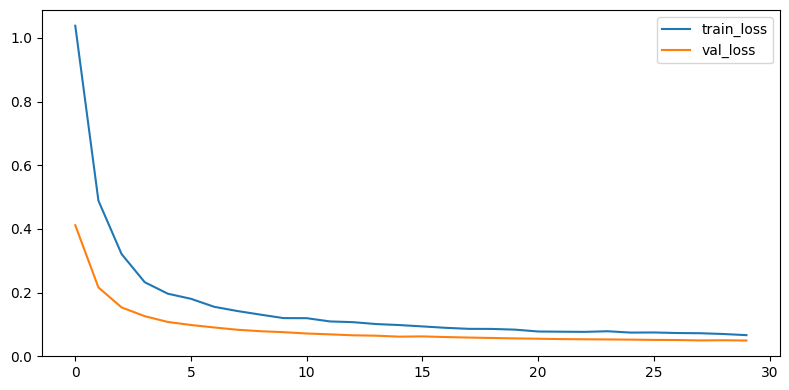

In [8]:
# Plot training curves (kept from original intent; safe if running headless)
plt.figure(figsize=(8, 4))
plt.plot(history.history.get("loss", []), label="train_loss")
plt.plot(history.history.get("val_loss", []), label="val_loss")
plt.legend()
plt.tight_layout()
plt.show()



In [9]:
# Predict probabilities on test set (DO NOT round; ROC AUC expects probabilities)
pre = model.predict(X_test_pp, batch_size=128, verbose=0).reshape(-1)

# Build submission using the sample submission ordering
test = sub.copy()
test["has_cactus"] = pre.astype(np.float32)

print(test.head())
print("pred min/max:", float(test["has_cactus"].min()), float(test["has_cactus"].max()))



                                     id  has_cactus
0  09034a34de0e2015a8a28dfe18f423f6.jpg    0.980376
1  134f04305c795d6d202502c2ce3578f3.jpg    1.000000
2  41fad8d145e6c41868ce3617e30a2545.jpg    0.999879
3  35f8a11352c8d41b6231bb33d8d09f7e.jpg    0.998609
4  b77dc902b035887cbbc01920ce0e3151.jpg    0.999989
pred min/max: 1.9633670245156054e-09 1.0


In [10]:
# Write valid submission CSV with correct name/suffix and columns
OUT_PATH = "submission.csv"
test.to_csv(OUT_PATH, index=False)
print("Wrote:", OUT_PATH, "shape:", test.shape)
print(test.head())

Wrote: submission.csv shape: (3325, 2)
                                     id  has_cactus
0  09034a34de0e2015a8a28dfe18f423f6.jpg    0.980376
1  134f04305c795d6d202502c2ce3578f3.jpg    1.000000
2  41fad8d145e6c41868ce3617e30a2545.jpg    0.999879
3  35f8a11352c8d41b6231bb33d8d09f7e.jpg    0.998609
4  b77dc902b035887cbbc01920ce0e3151.jpg    0.999989
